#### Anomaly Detection

##### Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from pathlib import Path

In [2]:
project_root = Path.cwd().parent
processed_dir = project_root/'data'/'processed'
figures_dir = project_root/'reports'/'figures'

In [3]:
features = pd.read_parquet(processed_dir/'station_archetypes.parquet')
features_scaled = pd.read_parquet(processed_dir/'station_features_scaled.parquet')
long = pd.read_parquet(processed_dir/'station_time.parquet')

##### Isolation Forest

In [4]:
X = features_scaled.values

In [5]:
iso = IsolationForest(contamination=0.05, random_state=69)

In [6]:
# -1 = Anomaly, 1 = Normal

features['anomaly'] = iso.fit_predict(X)
features['anomaly_score'] = iso.decision_function(X)

In [11]:
# 22 Anomaly Stations

(features['anomaly'] == -1).sum()

np.int64(22)

##### DBSCAN

In [12]:
db = DBSCAN(eps=1.5, min_samples=5).fit_predict(X)
features['dbscan_noise'] = (db == -1)

In [14]:
# DBSCAN shows 106 Stations as noise

features['dbscan_noise'].value_counts()

dbscan_noise
False    326
True     106
Name: count, dtype: int64

In [16]:
# 21 Stations flagged by Both Isolation Forest & DBSCAN

both = ((features["anomaly"] == -1) & features["dbscan_noise"]).sum()
both

np.int64(21)

##### Anomalies

In [24]:
features[features['anomaly'] == -1].sort_values('anomaly_score')

,log_total_weekday,early_share,eve_share,late_share,peakness,am_asym,pm_asym,weekend_shift,weekend_ratio,lines_served,interchange_ratio,cluster_k,cluster_hier,cluster_dbscan,station_name,archetype,anomaly,anomaly_score,dbscan_noise
nlc,,,,,,,,,,,,,,,,,,,
513,11.356027,0.008740,0.185599,0.071036,0.052727,-0.813418,0.562982,0.242048,0.321556,6,0.538560,4,6,-1,Bank and Monument,Central Mega-Interchanges,-1,-0.114294,True
631,10.597750,0.004965,0.294023,0.224367,0.039137,-0.773083,-0.039066,0.102167,1.561952,2,0.422784,4,6,-1,Leicester Square,Central Mega-Interchanges,-1,-0.112881,True
674,10.675992,0.002905,0.273586,0.189648,0.032523,-0.830934,0.122245,0.086049,1.320928,2,0.278189,4,6,-1,Piccadilly Circus,Central Mega-Interchanges,-1,-0.075595,True
688,5.726627,0.134162,0.024262,0.004438,0.090301,0.793737,-0.708466,0.239327,0.527828,1,0.000000,0,4,-1,Roding Valley,Outer Residential Origins,-1,-0.072135,True
728,11.460564,0.005105,0.242788,0.155250,0.034160,-0.771466,0.159479,0.092914,1.096747,3,0.522303,4,6,-1,Tottenham Court Road,Central Mega-Interchanges,-1,-0.062350,True
590,10.845369,0.005435,0.206017,0.127580,0.037283,-0.865848,0.353384,0.128528,0.705181,3,0.602710,4,6,-1,Green Park,Central Mega-Interchanges,-1,-0.035337,True
587,6.436587,0.176860,0.018247,0.003372,0.079824,0.749393,-0.729394,0.444315,0.592737,1,0.000000,0,4,-1,Grange Hill,Outer Residential Origins,-1,-0.032924,True
645,10.716427,0.007191,0.193603,0.069220,0.052613,-0.828396,0.560605,0.261730,0.350588,3,0.000000,5,2,-1,Moorgate,Central Workplace Destinations,-1,-0.031848,True
553,9.863002,0.001740,0.260721,0.155067,0.031456,-0.813039,-0.041639,0.065733,1.255985,1,0.000000,5,2,-1,Covent Garden,Central Workplace Destinations,-1,-0.031502,True


In [26]:
colors = features['anomaly'].map({1:'dodgerblue', -1:'crimson'})

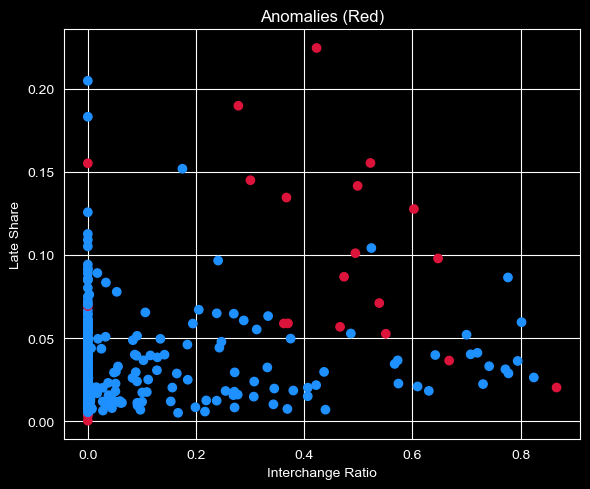

In [39]:
plt.figure(figsize=(6,5))
plt.scatter(features['interchange_ratio'], features['late_share'], c=colors)
plt.xlabel('Interchange Ratio')
plt.ylabel('Late Share')
plt.title('Anomalies (Red)')

plt.tight_layout()
plt.savefig(figures_dir/'anomaly_1.png', dpi=120)
plt.show()

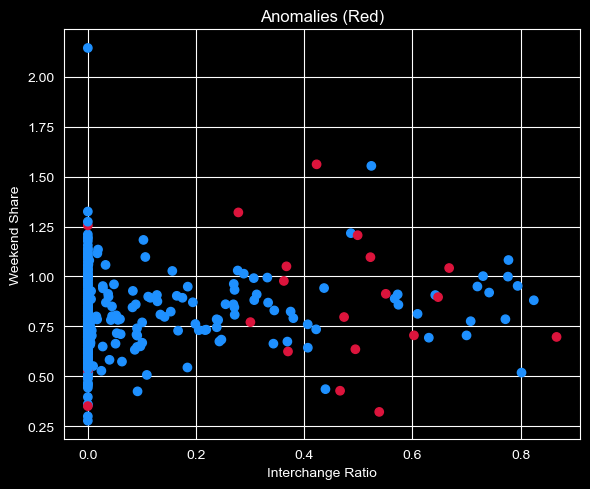

In [40]:
plt.figure(figsize=(6,5))
plt.scatter(features['interchange_ratio'], features['weekend_ratio'], c=colors)
plt.xlabel('Interchange Ratio')
plt.ylabel('Weekend Share')
plt.title('Anomalies (Red)')

plt.tight_layout()
plt.savefig(figures_dir/'anomaly_2.png', dpi=120)
plt.show()

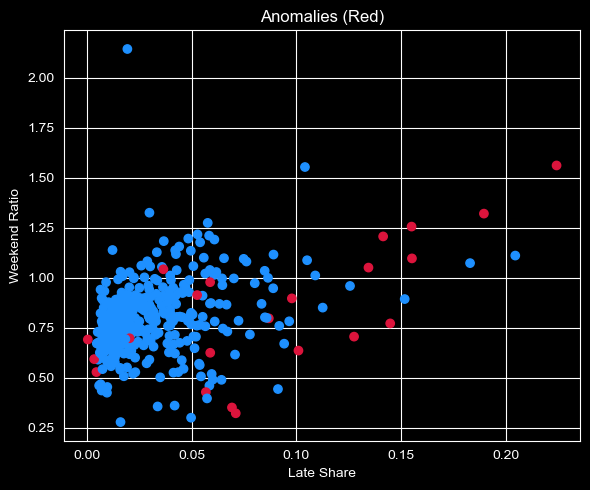

In [41]:
plt.figure(figsize=(6,5))
plt.scatter(features['late_share'], features['weekend_ratio'], c=colors)
plt.xlabel('Late Share')
plt.ylabel('Weekend Ratio')
plt.title('Anomalies (Red)')

plt.tight_layout()
plt.savefig(figures_dir/'anomaly_3.png', dpi=120)
plt.show()

In [42]:
# Saving
features.to_parquet(processed_dir/'station_anomaly.parquet')

#### Summary

An anomaly here is a station which has extreme characteristics so it barely fits its nearest archetype.

**1. West End night-and-weekend stations** - Leicester Square (`late_share` 0.22, `weekend_ratio` 1.56), Piccadilly Circus (0.19, 1.32), Covent Garden (0.16, 1.26). These are unusual because they combine very high late-night activity, are busier on
weekends than weekdays and are central. This is a mix almost no ordinary station has and they show us London nightlife and tourism core.

**2. Extreme mega-hubs** - West Ham (`interchange_ratio` 0.86, the highest in the network), Bank & Monument (0.50), Stratford (0.66), Oxford Circus (0.63), King's Cross, Tottenham Court Road. Unusual because of the interchange and size: at these
stations most movement is people changing trains, which is anextreme value than the typical station.

**3. Tiny outliers** - Grange Hill, Roding Valley, Emerson Park: very small, single line,
no interchange outer stops whose feature combination sits far from the dense centre of
the network in the opposite direction to the hubs.

The pair plots show why: plotted on `interchange_ratio`, `late_share` and `weekend_ratio`,
the red anomalies occupy the extreme corners of the feature space, separated from
the blue mass of typical stations.

The anomalies are not errors to remove but they are London's most distinctive stations.